# Visualise ASHD and AEDP 148-Household Profiles

This notebook compares the aggregate 148-household ASHD and AEDP net-load profiles with Sydney Airport air temperature. The comparison is exploratory: the datasets cover different calendar years, so the plots compare recurring behaviour by week slot, day slot, season, and temperature rather than matching the same dates.

Datasets:

- ASHD: `data/ds20_ashd_148hh_with_weather.csv`
- AEDP: `data/ds11_aedp_cluster2_30min_with_weather.csv`


## 1. Setup

Load pandas/numpy/matplotlib, define input paths, figure paths, colours, and small helpers for saving publication-style exploratory plots.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start=None):
    """Find the PyNNLF repository root from the current working directory."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the PyNNLF repository root.")


REPO_ROOT = find_repo_root()
PUBLICATION_DIR = REPO_ROOT / "publication" / "journal_article_1"
FIGURE_DIR = PUBLICATION_DIR / "results" / "01_ashd_aedp_148hh_comparison" / "figures" / "profile_exploration"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ASHD_PATH = REPO_ROOT / "data" / "ds20_ashd_148hh_with_weather.csv"
AEDP_PATH = REPO_ROOT / "data" / "ds11_aedp_cluster2_30min_with_weather.csv"

DATASET_ORDER = ["ASHD 148 households", "AEDP 148 households"]
COLORS = {
    "ASHD 148 households": "#2F4D67",
    "AEDP 148 households": "#EB932C",
    "Temperature": "#9B2D30",
}
SEASON_ORDER = ["Summer (DJF)", "Autumn (MAM)", "Winter (JJA)", "Spring (SON)"]
SEASON_MAP = {
    12: "Summer (DJF)", 1: "Summer (DJF)", 2: "Summer (DJF)",
    3: "Autumn (MAM)", 4: "Autumn (MAM)", 5: "Autumn (MAM)",
    6: "Winter (JJA)", 7: "Winter (JJA)", 8: "Winter (JJA)",
    9: "Spring (SON)", 10: "Spring (SON)", 11: "Spring (SON)",
}
DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})


def save_figure(fig, filename):
    """Save a figure into the publication result figure directory and keep it visible inline."""
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved {path}")
    return path


def style_time_axis(ax, week=False):
    """Format x-axis labels for daily or weekly half-hour slot plots."""
    if week:
        ticks = np.arange(0, 7 * 48, 48)
        ax.set_xticks(ticks)
        ax.set_xticklabels(DAY_LABELS)
        ax.set_xlim(0, 7 * 48 - 1)
        ax.set_xlabel("Day of week")
    else:
        ticks = np.arange(0, 49, 8)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{int(t // 2):02d}:00" for t in ticks])
        ax.set_xlim(0, 47)
        ax.set_xlabel("Time of day")
    ax.grid(alpha=0.25)


print(f"Repository root: {REPO_ROOT}")
print(f"Figure output folder: {FIGURE_DIR}")


Repository root: C:\Users\z5404477\Documents\PyNNLF
Figure output folder: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\profile_exploration


## 2. Load and validate datasets

Both datasets should contain 148-household aggregate `netload_kW` and Sydney Airport `air_temperature_in_degrees_c`. The notebook adds time features used for profile grouping.

In [2]:
REQUIRED_COLUMNS = ["datetime", "netload_kW", "air_temperature_in_degrees_c"]


def load_profile_dataset(path, label):
    """Load one dataset, validate the required columns, and add profile grouping columns."""
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path, parse_dates=["datetime"])
    missing_columns = [column for column in REQUIRED_COLUMNS if column not in df.columns]
    if missing_columns:
        raise ValueError(f"{path.name} is missing required columns: {missing_columns}")

    df = df[REQUIRED_COLUMNS].copy()
    df.insert(0, "dataset", label)
    df = df.sort_values("datetime").reset_index(drop=True)

    if df.shape[0] != 52_608:
        raise AssertionError(f"{path.name} expected 52,608 rows, found {df.shape[0]:,}")
    if df["datetime"].duplicated().any():
        raise AssertionError(f"{path.name} contains duplicate timestamps")
    if df[["netload_kW", "air_temperature_in_degrees_c"]].isna().any().any():
        raise AssertionError(f"{path.name} contains missing net load or temperature values")

    freq_minutes = df["datetime"].diff().dropna().dt.total_seconds().div(60).unique()
    if len(freq_minutes) != 1 or freq_minutes[0] != 30:
        raise AssertionError(f"{path.name} does not have regular 30-minute spacing")

    df["dayofweek"] = df["datetime"].dt.dayofweek
    df["day_name"] = pd.Categorical(df["datetime"].dt.day_name().str[:3], categories=DAY_LABELS, ordered=True)
    df["half_hour_slot"] = df["datetime"].dt.hour * 2 + df["datetime"].dt.minute // 30
    df["week_slot"] = df["dayofweek"] * 48 + df["half_hour_slot"]
    df["month"] = df["datetime"].dt.month
    df["season"] = pd.Categorical(df["month"].map(SEASON_MAP), categories=SEASON_ORDER, ordered=True)
    df["year"] = df["datetime"].dt.year
    return df


ashd = load_profile_dataset(ASHD_PATH, DATASET_ORDER[0])
aedp = load_profile_dataset(AEDP_PATH, DATASET_ORDER[1])
profiles = pd.concat([ashd, aedp], ignore_index=True)
profiles["dataset"] = pd.Categorical(profiles["dataset"], categories=DATASET_ORDER, ordered=True)

summary = (
    profiles
    .groupby("dataset", observed=True)
    .agg(
        rows=("datetime", "size"),
        start=("datetime", "min"),
        end=("datetime", "max"),
        netload_mean_kW=("netload_kW", "mean"),
        netload_std_kW=("netload_kW", "std"),
        netload_min_kW=("netload_kW", "min"),
        netload_median_kW=("netload_kW", "median"),
        netload_max_kW=("netload_kW", "max"),
        temp_mean_C=("air_temperature_in_degrees_c", "mean"),
        temp_min_C=("air_temperature_in_degrees_c", "min"),
        temp_max_C=("air_temperature_in_degrees_c", "max"),
    )
)
display(summary.round(3))
display(profiles.head())


,rows,start,end,netload_mean_kW,netload_std_kW,netload_min_kW,netload_median_kW,netload_max_kW,temp_mean_C,temp_min_C,temp_max_C
dataset,,,,,,,,,,,
ASHD 148 households,52608,2010-07-01,2013-06-30 23:30:00,71.051,67.257,-112.814,66.509,375.170,18.256,5.3,45.5
AEDP 148 households,52608,2021-07-01,2024-06-30 23:30:00,7.193,116.219,-411.704,24.367,276.618,18.460,5.4,43.0


,dataset,datetime,netload_kW,air_temperature_in_degrees_c,dayofweek,day_name,half_hour_slot,week_slot,month,season,year
0,ASHD 148 households,2010-07-01 00:00:00,106.446,8.4,3,Thu,0,144,7,Winter (JJA),2010
1,ASHD 148 households,2010-07-01 00:30:00,107.454,7.9,3,Thu,1,145,7,Winter (JJA),2010
2,ASHD 148 households,2010-07-01 01:00:00,97.336,7.5,3,Thu,2,146,7,Winter (JJA),2010
3,ASHD 148 households,2010-07-01 01:30:00,89.238,7.4,3,Thu,3,147,7,Winter (JJA),2010
4,ASHD 148 households,2010-07-01 02:00:00,81.964,7.2,3,Thu,4,148,7,Winter (JJA),2010


## 3. Typical weekly net-load profile

Average each dataset by 30-minute week slot. The shaded band shows the interquartile range for the same week slot across all weeks.

Saved C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\profile_exploration\fig01_typical_weekly_netload.png


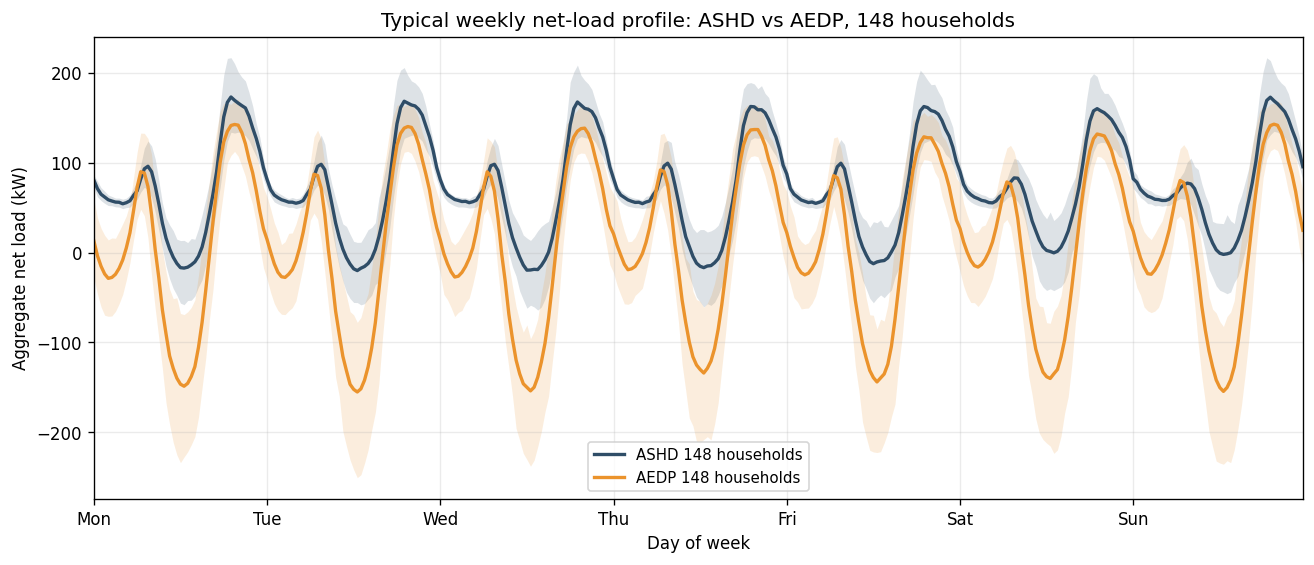

In [3]:
weekly_stats = (
    profiles
    .groupby(["dataset", "week_slot"], observed=True)
    .agg(
        mean_netload=("netload_kW", "mean"),
        q25_netload=("netload_kW", lambda x: x.quantile(0.25)),
        q75_netload=("netload_kW", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
for label in DATASET_ORDER:
    part = weekly_stats[weekly_stats["dataset"] == label].sort_values("week_slot")
    x = part["week_slot"].to_numpy(dtype=float)
    mean = part["mean_netload"].to_numpy(dtype=float)
    q25 = part["q25_netload"].to_numpy(dtype=float)
    q75 = part["q75_netload"].to_numpy(dtype=float)
    ax.plot(x, mean, color=COLORS[label], linewidth=2, label=label)
    ax.fill_between(x, q25, q75, color=COLORS[label], alpha=0.16, linewidth=0)

style_time_axis(ax, week=True)
ax.set_ylabel("Aggregate net load (kW)")
ax.set_title("Typical weekly net-load profile: ASHD vs AEDP, 148 households")
ax.legend(loc="best")
save_figure(fig, "fig01_typical_weekly_netload.png")
plt.show()


## 4. Weekly net load and air temperature

For each dataset, plot mean weekly net load and mean Sydney Airport air temperature together. The dual axis is exploratory; it helps show whether temperature and load peaks line up by recurring week slot.

Saved C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\profile_exploration\fig02_weekly_netload_temperature.png


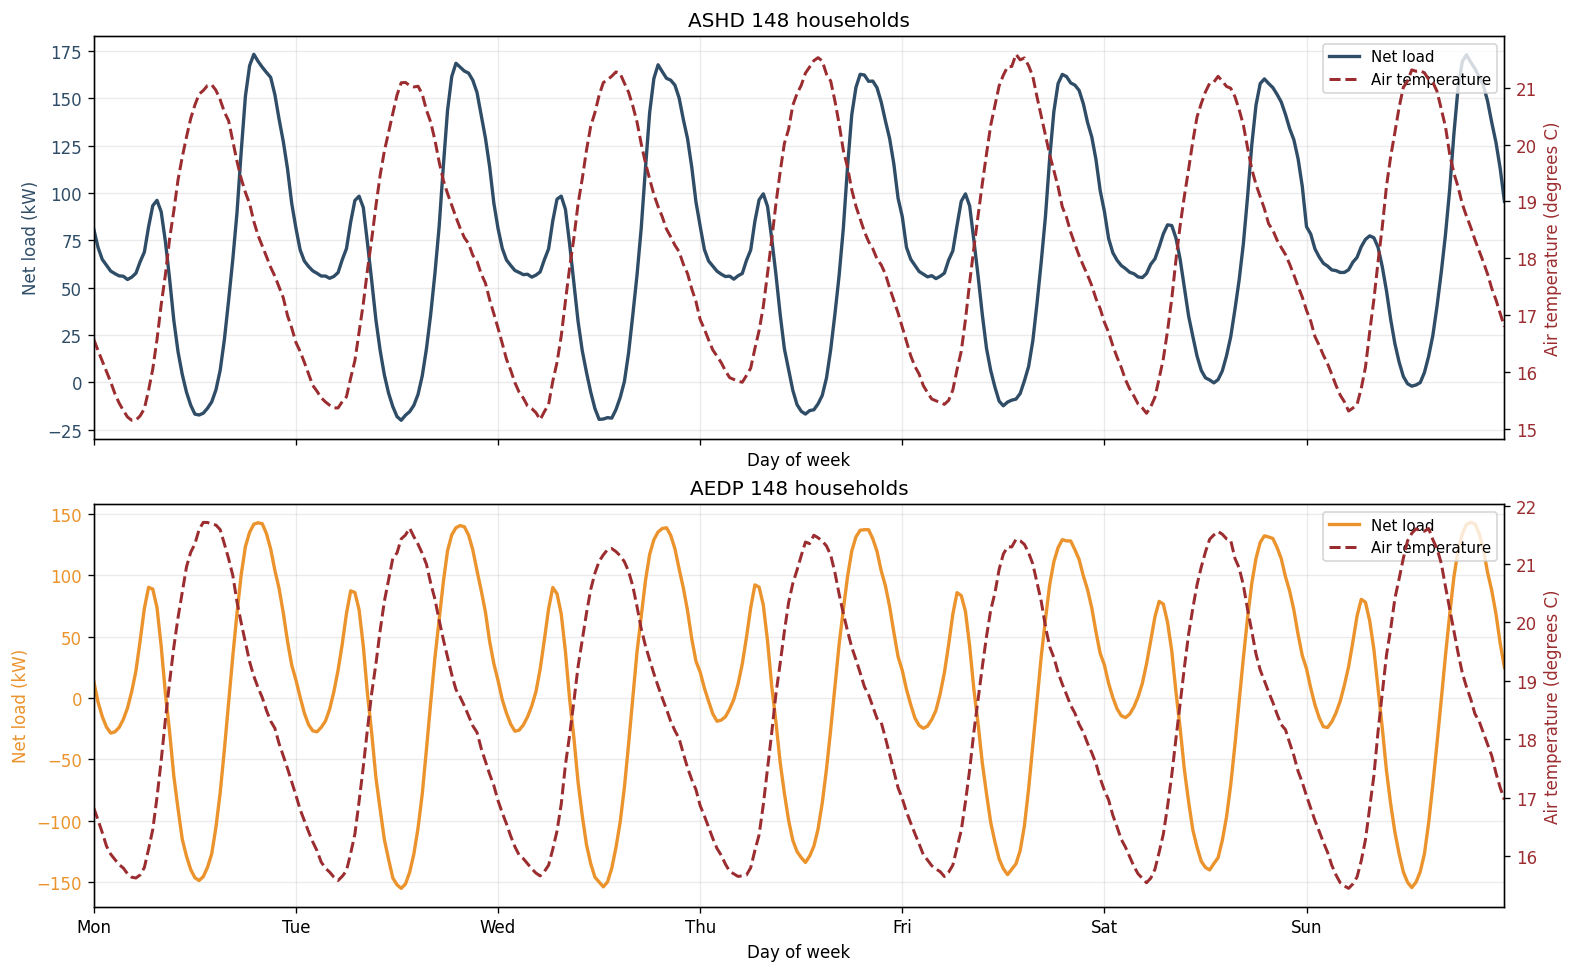

In [4]:
weekly_load_temp = (
    profiles
    .groupby(["dataset", "week_slot"], observed=True)
    .agg(
        mean_netload=("netload_kW", "mean"),
        mean_temperature=("air_temperature_in_degrees_c", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, constrained_layout=True)
for ax, label in zip(axes, DATASET_ORDER):
    part = weekly_load_temp[weekly_load_temp["dataset"] == label].sort_values("week_slot")
    x = part["week_slot"].to_numpy(dtype=float)
    load = part["mean_netload"].to_numpy(dtype=float)
    temp = part["mean_temperature"].to_numpy(dtype=float)

    ax.plot(x, load, color=COLORS[label], linewidth=2, label="Net load")
    ax.set_ylabel("Net load (kW)", color=COLORS[label])
    ax.tick_params(axis="y", labelcolor=COLORS[label])
    style_time_axis(ax, week=True)

    temp_ax = ax.twinx()
    temp_ax.plot(x, temp, color=COLORS["Temperature"], linewidth=1.8, linestyle="--", label="Air temperature")
    temp_ax.set_ylabel("Air temperature (degrees C)", color=COLORS["Temperature"])
    temp_ax.tick_params(axis="y", labelcolor=COLORS["Temperature"])

    lines = ax.get_lines() + temp_ax.get_lines()
    ax.legend(lines, [line.get_label() for line in lines], loc="upper right")
    ax.set_title(label)

save_figure(fig, "fig02_weekly_netload_temperature.png")
plt.show()


## 5. Seasonal typical daily net-load profiles

For each Australian season, average by 30-minute time-of-day slot. This reveals whether the daytime PV-shaped dip and evening peaks differ between ASHD and AEDP.

Saved C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\profile_exploration\fig03_seasonal_daily_netload.png


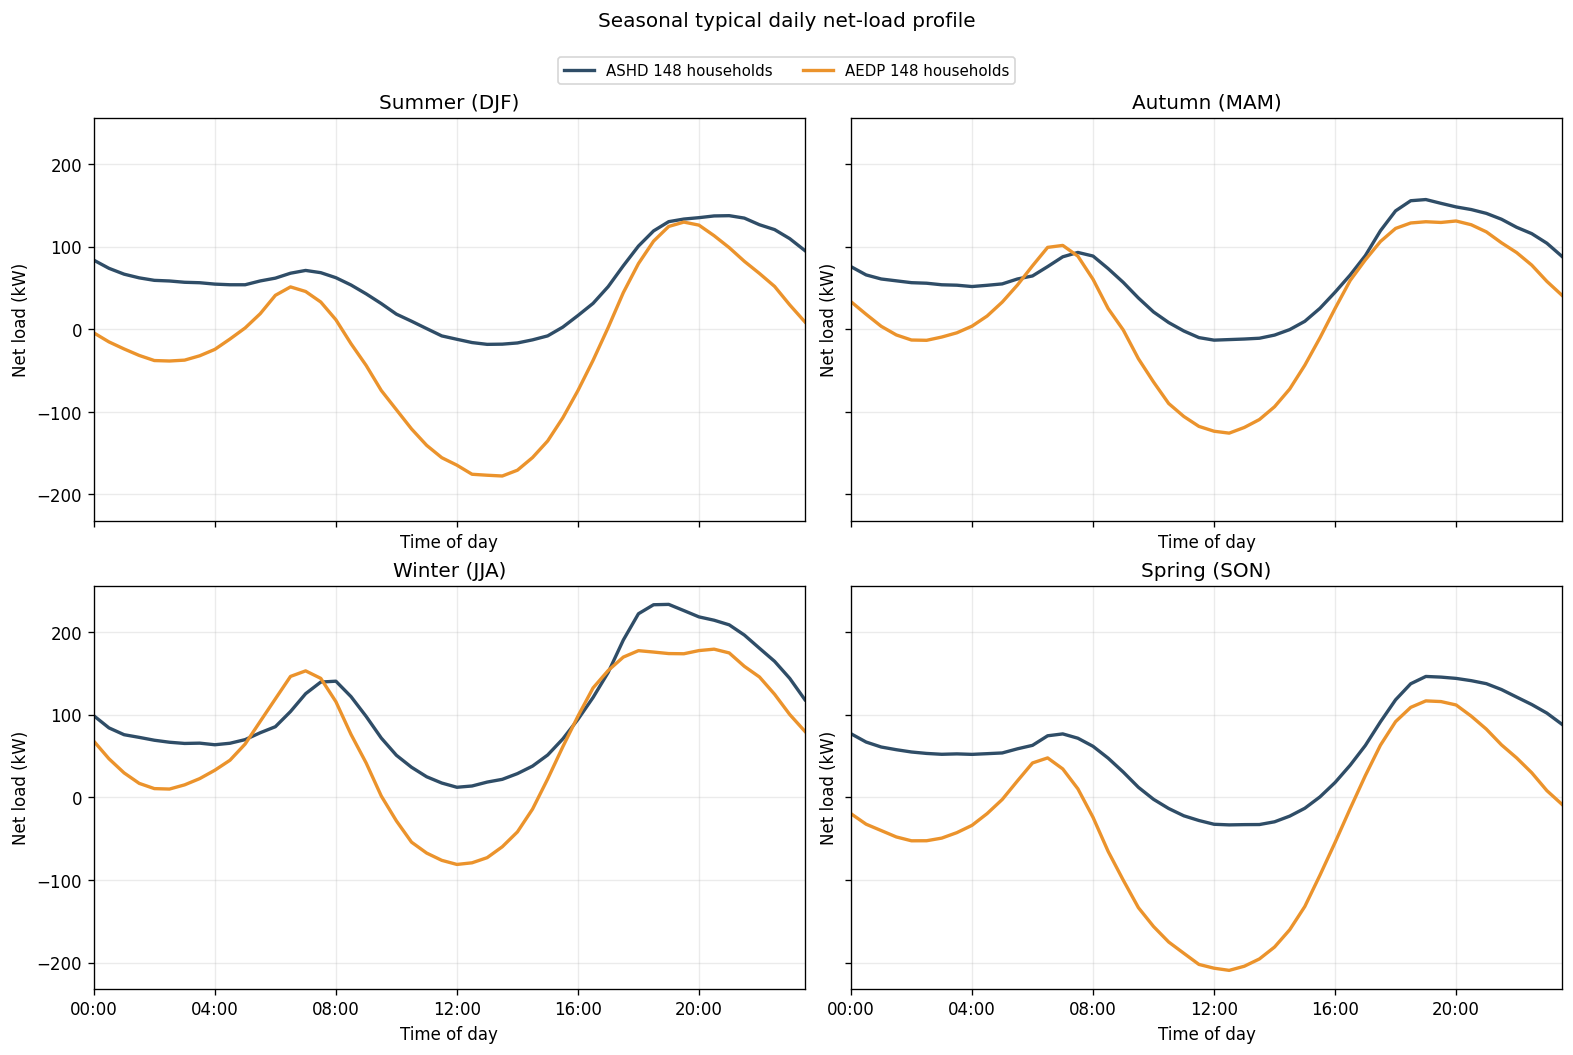

In [5]:
season_daily_load = (
    profiles
    .groupby(["dataset", "season", "half_hour_slot"], observed=True)
    .agg(mean_netload=("netload_kW", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True, constrained_layout=True)
for ax, season in zip(axes.flat, SEASON_ORDER):
    for label in DATASET_ORDER:
        part = season_daily_load[
            (season_daily_load["dataset"] == label) &
            (season_daily_load["season"] == season)
        ].sort_values("half_hour_slot")
        ax.plot(
            part["half_hour_slot"],
            part["mean_netload"],
            color=COLORS[label],
            linewidth=2,
            label=label,
        )
    style_time_axis(ax, week=False)
    ax.set_title(season)
    ax.set_ylabel("Net load (kW)")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Seasonal typical daily net-load profile", y=1.08)
save_figure(fig, "fig03_seasonal_daily_netload.png")
plt.show()


## 6. Seasonal daily net load and air temperature

The panels below show net load and air temperature together by season for each dataset. This makes it easier to see whether the seasonal load shape coincides with the temperature shape.

Saved C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\profile_exploration\fig04_ashd_seasonal_daily_netload_temperature.png


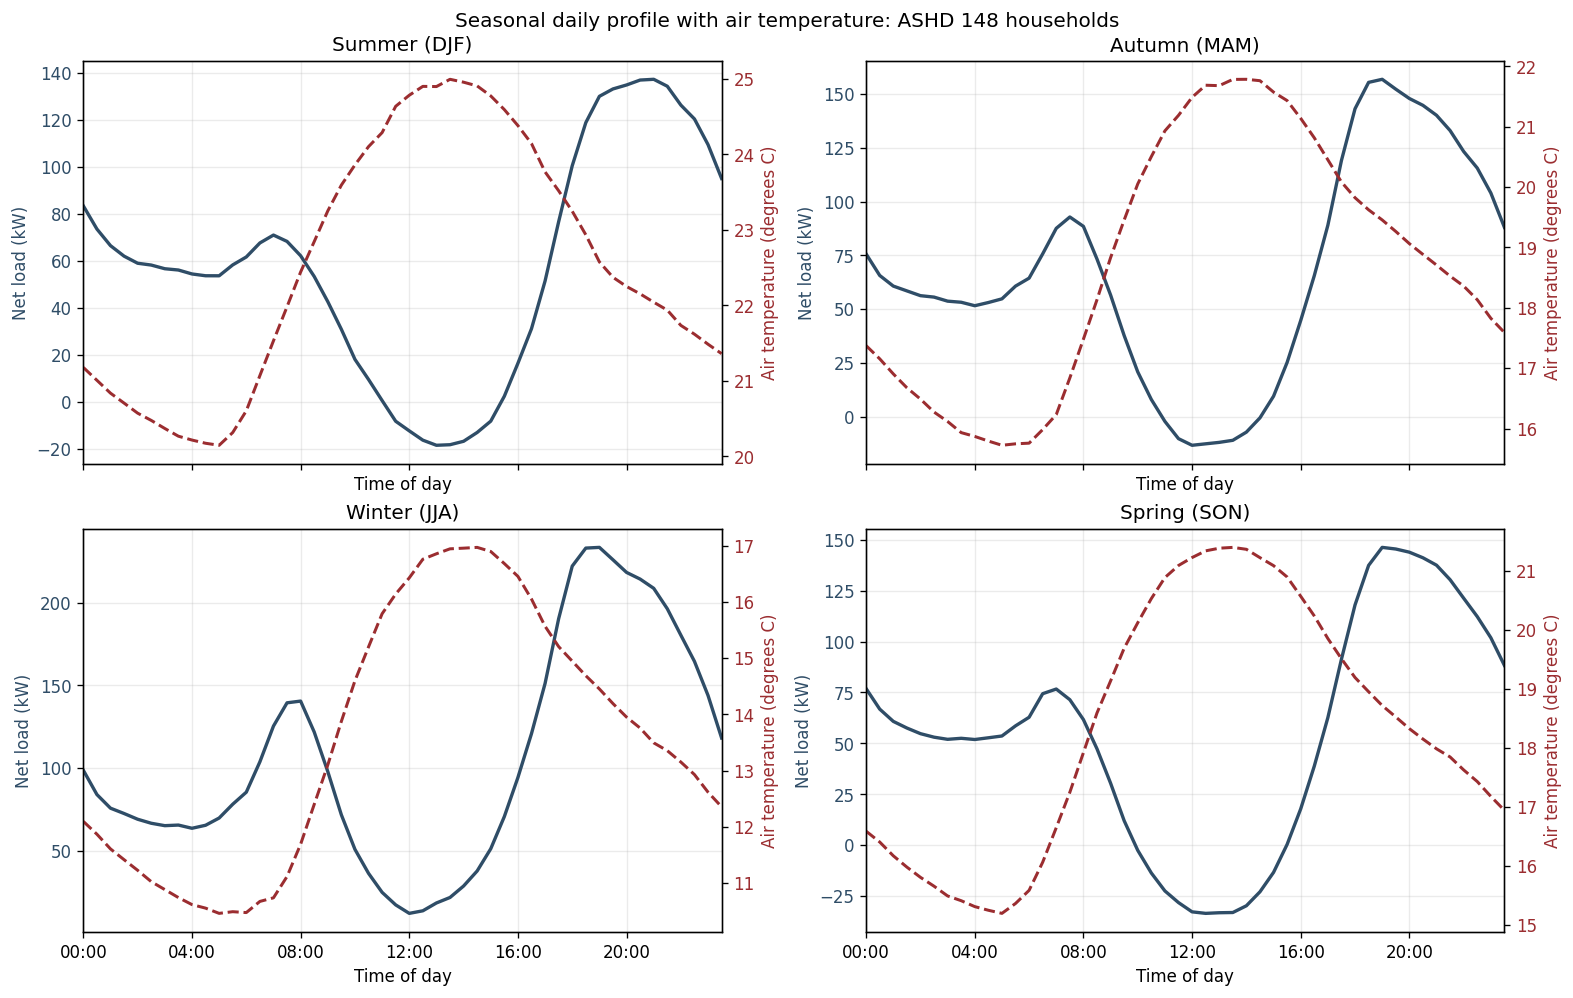

Saved C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\profile_exploration\fig04_aedp_seasonal_daily_netload_temperature.png


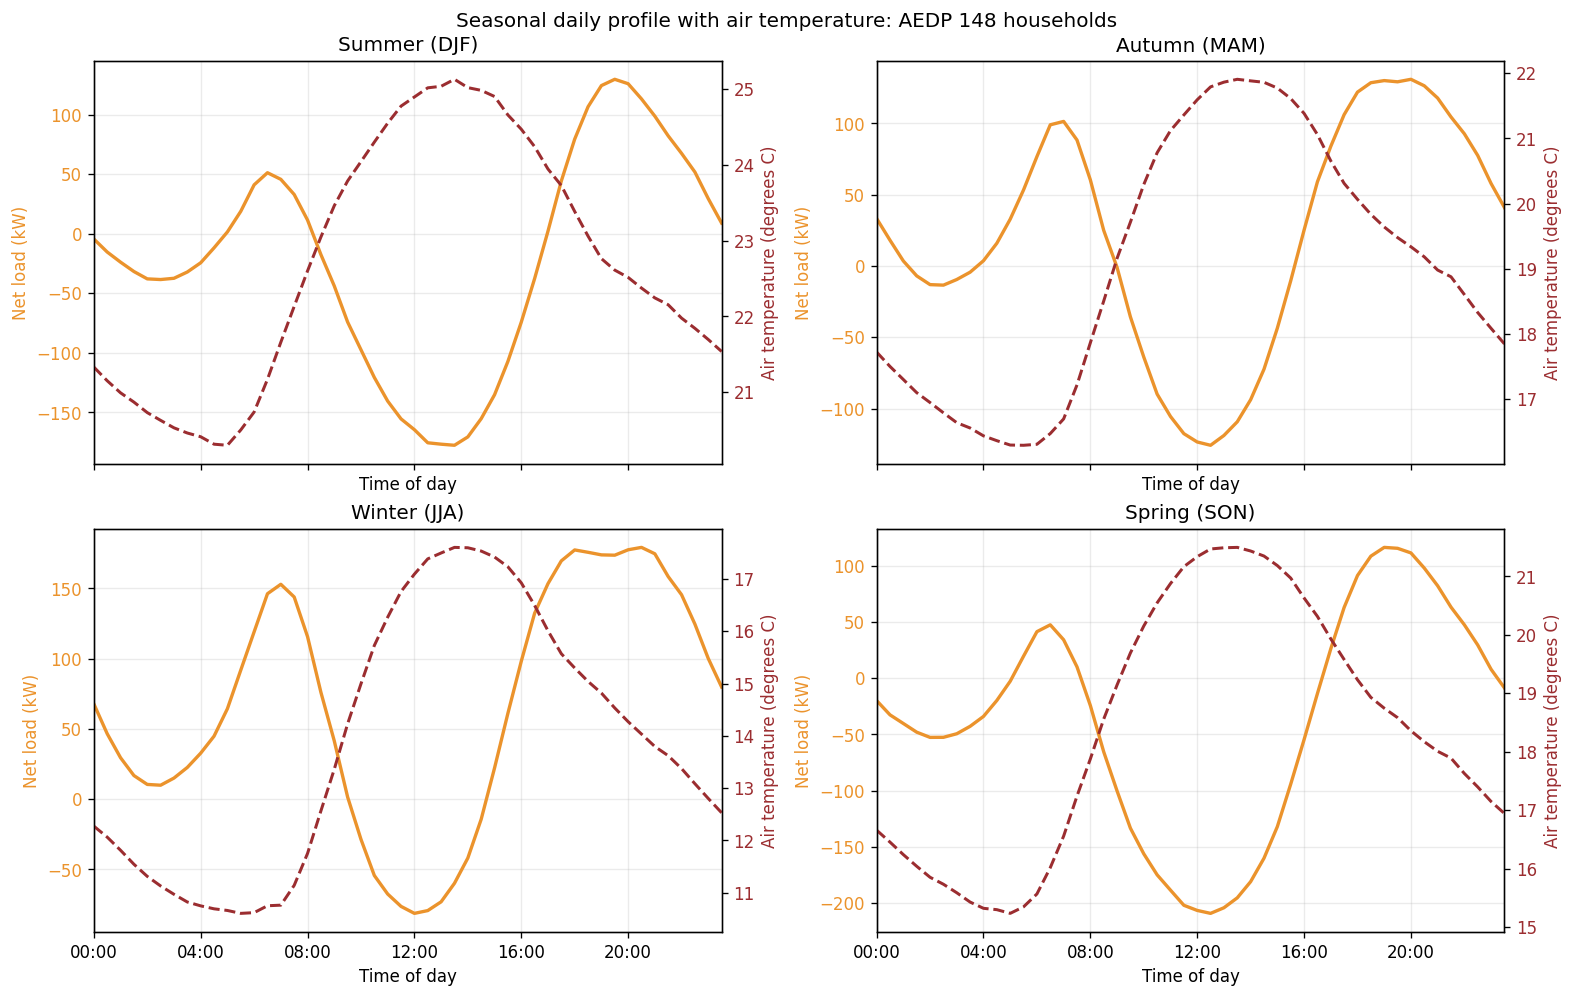

In [6]:
season_daily_load_temp = (
    profiles
    .groupby(["dataset", "season", "half_hour_slot"], observed=True)
    .agg(
        mean_netload=("netload_kW", "mean"),
        mean_temperature=("air_temperature_in_degrees_c", "mean"),
    )
    .reset_index()
)

for label in DATASET_ORDER:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, constrained_layout=True)
    for ax, season in zip(axes.flat, SEASON_ORDER):
        part = season_daily_load_temp[
            (season_daily_load_temp["dataset"] == label) &
            (season_daily_load_temp["season"] == season)
        ].sort_values("half_hour_slot")
        x = part["half_hour_slot"].to_numpy(dtype=float)
        load = part["mean_netload"].to_numpy(dtype=float)
        temp = part["mean_temperature"].to_numpy(dtype=float)

        ax.plot(x, load, color=COLORS[label], linewidth=2, label="Net load")
        ax.set_ylabel("Net load (kW)", color=COLORS[label])
        ax.tick_params(axis="y", labelcolor=COLORS[label])
        style_time_axis(ax, week=False)
        ax.set_title(season)

        temp_ax = ax.twinx()
        temp_ax.plot(x, temp, color=COLORS["Temperature"], linestyle="--", linewidth=1.8, label="Air temperature")
        temp_ax.set_ylabel("Air temperature (degrees C)", color=COLORS["Temperature"])
        temp_ax.tick_params(axis="y", labelcolor=COLORS["Temperature"])

    fig.suptitle(f"Seasonal daily profile with air temperature: {label}", y=1.02)
    safe_label = "ashd" if label.startswith("ASHD") else "aedp"
    save_figure(fig, f"fig04_{safe_label}_seasonal_daily_netload_temperature.png")
    plt.show()


## 7. Net-load distributions

Compare the full half-hourly net-load distribution and the seasonal distributions. Negative net load indicates aggregate export during high PV periods.

Saved C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\profile_exploration\fig05_netload_distributions.png


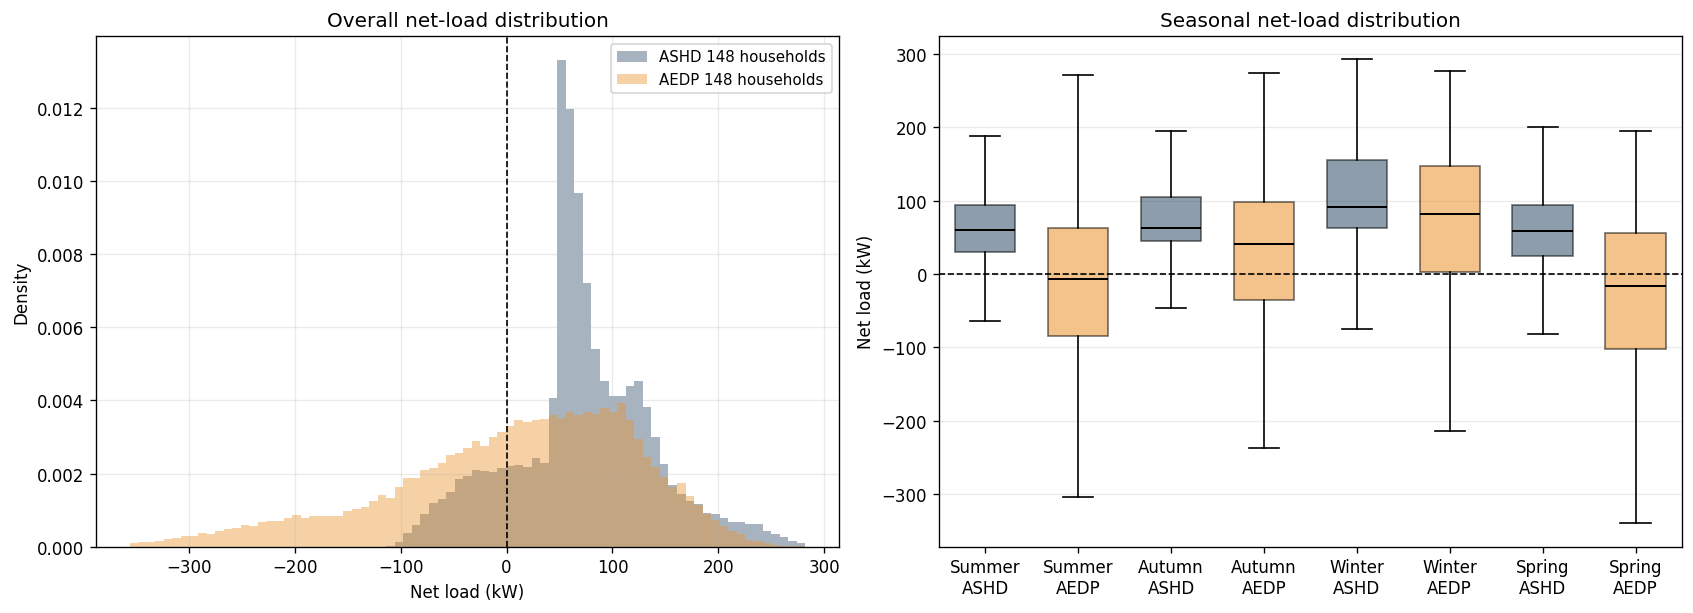

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

bins = np.linspace(
    profiles["netload_kW"].quantile(0.001),
    profiles["netload_kW"].quantile(0.999),
    80,
)
for label in DATASET_ORDER:
    part = profiles[profiles["dataset"] == label]
    axes[0].hist(
        part["netload_kW"],
        bins=bins,
        density=True,
        alpha=0.42,
        color=COLORS[label],
        label=label,
    )
axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Overall net-load distribution")
axes[0].set_xlabel("Net load (kW)")
axes[0].set_ylabel("Density")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.25)

box_data = []
box_labels = []
box_colors = []
for season in SEASON_ORDER:
    for label in DATASET_ORDER:
        box_data.append(profiles.loc[(profiles["season"] == season) & (profiles["dataset"] == label), "netload_kW"])
        box_labels.append((season.split()[0], "ASHD" if label.startswith("ASHD") else "AEDP"))
        box_colors.append(COLORS[label])

positions = np.arange(len(box_data))
box = axes[1].boxplot(box_data, positions=positions, widths=0.65, patch_artist=True, showfliers=False)
for patch, color in zip(box["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.2)
axes[1].set_xticks(positions)
axes[1].set_xticklabels([f"{season}\n{dataset}" for season, dataset in box_labels], rotation=0)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Seasonal net-load distribution")
axes[1].set_ylabel("Net load (kW)")
axes[1].grid(axis="y", alpha=0.25)

save_figure(fig, "fig05_netload_distributions.png")
plt.show()


## 8. Net load vs air temperature

Dense scatter plots show half-hourly net load against Sydney Airport air temperature. The black line is the binned mean net load by 1-degree temperature bands.

Saved C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\profile_exploration\fig06_netload_vs_temperature.png


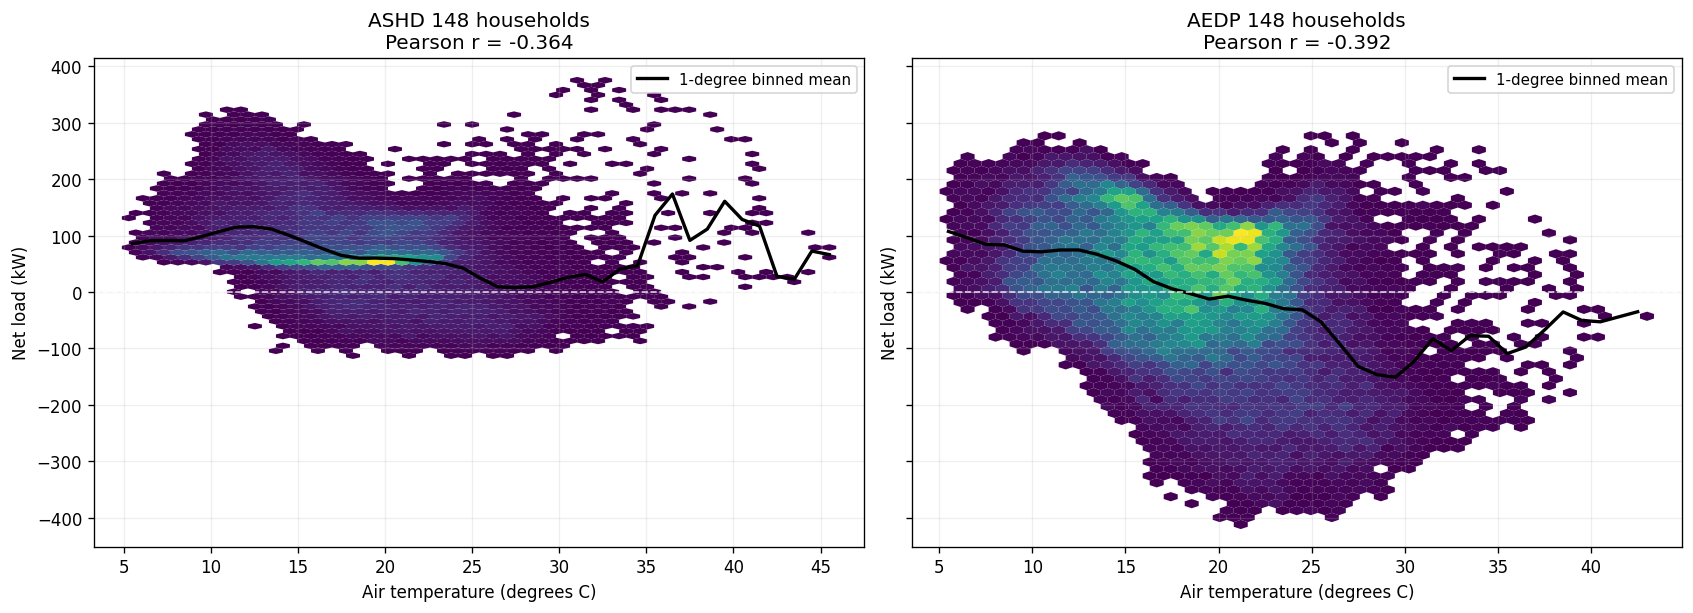

,dataset,pearson_corr_netload_temperature
0,ASHD 148 households,-0.364
1,AEDP 148 households,-0.392


In [8]:
def binned_temperature_mean(df, bin_width=1.0):
    """Return mean net load by temperature bin midpoint."""
    temp_min = np.floor(df["air_temperature_in_degrees_c"].min())
    temp_max = np.ceil(df["air_temperature_in_degrees_c"].max())
    bins = np.arange(temp_min, temp_max + bin_width, bin_width)
    temp_bin = pd.cut(df["air_temperature_in_degrees_c"], bins=bins, include_lowest=True)
    grouped = df.groupby(temp_bin, observed=True)["netload_kW"].mean().reset_index()
    grouped["temperature_midpoint"] = grouped["air_temperature_in_degrees_c"].apply(lambda interval: interval.mid)
    return grouped.dropna(subset=["netload_kW", "temperature_midpoint"])


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, constrained_layout=True)
correlation_rows = []
for ax, label in zip(axes, DATASET_ORDER):
    part = profiles[profiles["dataset"] == label].copy()
    corr = part["netload_kW"].corr(part["air_temperature_in_degrees_c"])
    correlation_rows.append({"dataset": label, "pearson_corr_netload_temperature": corr})

    ax.hexbin(
        part["air_temperature_in_degrees_c"],
        part["netload_kW"],
        gridsize=50,
        mincnt=1,
        cmap="viridis",
        linewidths=0,
    )
    binned = binned_temperature_mean(part)
    ax.plot(
        binned["temperature_midpoint"],
        binned["netload_kW"],
        color="black",
        linewidth=2,
        label="1-degree binned mean",
    )
    ax.axhline(0, color="white", linewidth=1, linestyle="--", alpha=0.8)
    ax.set_title(f"{label}\nPearson r = {corr:.3f}")
    ax.set_xlabel("Air temperature (degrees C)")
    ax.set_ylabel("Net load (kW)")
    ax.legend(loc="best")
    ax.grid(alpha=0.2)

save_figure(fig, "fig06_netload_vs_temperature.png")
plt.show()

correlations = pd.DataFrame(correlation_rows)
display(correlations.round(3))


## 9. Extra profile summaries

These compact tables are useful while interpreting the plots: seasonal means, day/night means, and the share of half-hourly intervals with negative aggregate net load.

In [9]:
profiles["period"] = np.where(profiles["half_hour_slot"].between(14, 35), "Daytime 07:00-17:30", "Evening/night")

season_summary = (
    profiles
    .groupby(["dataset", "season"], observed=True)
    .agg(
        mean_netload_kW=("netload_kW", "mean"),
        median_netload_kW=("netload_kW", "median"),
        mean_temperature_C=("air_temperature_in_degrees_c", "mean"),
        negative_netload_pct=("netload_kW", lambda x: 100 * (x < 0).mean()),
    )
    .reset_index()
)
period_summary = (
    profiles
    .groupby(["dataset", "period"], observed=True)
    .agg(
        mean_netload_kW=("netload_kW", "mean"),
        median_netload_kW=("netload_kW", "median"),
        mean_temperature_C=("air_temperature_in_degrees_c", "mean"),
        negative_netload_pct=("netload_kW", lambda x: 100 * (x < 0).mean()),
    )
    .reset_index()
)

display(season_summary.round(3))
display(period_summary.round(3))


,dataset,season,mean_netload_kW,median_netload_kW,mean_temperature_C,negative_netload_pct
0,ASHD 148 households,Summer (DJF),57.712,59.426,22.517,16.413
1,ASHD 148 households,Autumn (MAM),66.564,63.434,18.717,14.523
2,ASHD 148 households,Winter (JJA),105.371,91.285,13.551,8.077
3,ASHD 148 households,Spring (SON),54.133,58.117,18.315,20.047
4,AEDP 148 households,Summer (DJF),-21.182,-6.264,22.680,52.076
5,AEDP 148 households,Autumn (MAM),20.518,41.346,19.027,35.447
6,AEDP 148 households,Winter (JJA),65.638,82.055,13.857,24.283
7,AEDP 148 households,Spring (SON),-37.197,-16.572,18.349,55.449


,dataset,period,mean_netload_kW,median_netload_kW,mean_temperature_C,negative_netload_pct
0,ASHD 148 households,Daytime 07:00-17:30,34.890,36.389,19.832,32.167
1,ASHD 148 households,Evening/night,101.650,82.912,16.922,0.000
2,AEDP 148 households,Daytime 07:00-17:30,-47.663,-39.650,20.046,60.277
3,AEDP 148 households,Evening/night,53.611,57.730,17.117,26.035


## 10. Notes from visual inspection

Use this space to record profile observations after inspecting the plots.

- ASHD vs AEDP weekly load shape:
- Seasonal differences:
- Temperature relationship:
- Distribution / negative net-load behaviour:


## 11. Figure outputs

The notebook saves the main figures locally so they can be reused in notes or slides.

In [10]:
figure_files = sorted(FIGURE_DIR.glob("*.png"))
print(f"Saved {len(figure_files)} figure files:")
for path in figure_files:
    print(f"- {path.name}")

expected_figures = {
    "fig01_typical_weekly_netload.png",
    "fig02_weekly_netload_temperature.png",
    "fig03_seasonal_daily_netload.png",
    "fig04_ashd_seasonal_daily_netload_temperature.png",
    "fig04_aedp_seasonal_daily_netload_temperature.png",
    "fig05_netload_distributions.png",
    "fig06_netload_vs_temperature.png",
}
missing = expected_figures - {path.name for path in figure_files}
if missing:
    raise AssertionError(f"Missing expected figure files: {sorted(missing)}")


Saved 7 figure files:
- fig01_typical_weekly_netload.png
- fig02_weekly_netload_temperature.png
- fig03_seasonal_daily_netload.png
- fig04_aedp_seasonal_daily_netload_temperature.png
- fig04_ashd_seasonal_daily_netload_temperature.png
- fig05_netload_distributions.png
- fig06_netload_vs_temperature.png
